# Play with `intake_esm`

I'm using this as a starting place to explore using Julius' `intake_esm` package to see which CMIP6 models might be candidates for the tropical circulation project. It appears this can also be used to load the data and convert it to an xr ds, but for right now I just want to see how far I get with querying.

In [68]:
import intake
import xarray as xr
import pandas as pd
import numpy as np
import gcsfs
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
cat_url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
col = intake.open_esm_datastore(cat_url)

## Notes

Variables:
- `thetao` (`sea_water_potential_temperature`):
- `so` (`sea_water_salinity`): usually practical salinity scale of 1978, but not necessarily
- `uo` (`sea_water_x_velocity`): zonal velocity
- `obvfsq` (`square_of_brunt_vaisala_frequency_in_sea_water`): buouyancy frequency

Experiment: 
- 'historical': data from 1850 based on a spun-up, pre-industrial control where the ocean and atmosphere state are freely evolving (note that radiative forcing is based on obs but NOT dynamics)

In [124]:
var_req = {'uo'}#, 'obvfsq'}

matches = col.search(activity_id = 'CMIP',              #coupled CMIP models
                     experiment_id = 'historical',      #free-running historical sims
                     table_id = 'Omon',                 #monthly ocean data
                     variable_id = var_req)             #variables of interest (OR search)

In [125]:
eligible = (matches.df.groupby(['source_id', 'member_id', 'grid_label'], dropna=False)
            ['variable_id']
            .agg(lambda x: set(x.dropna()))
            .loc[lambda found: found.apply(var_req.issubset)]
            .reset_index(name='available_variables'))

eligible["available_variables"] = eligible["available_variables"].apply(
    lambda x: ", ".join(sorted(x))
)

eligible = eligible.sort_values(
    ["source_id", "member_id", "grid_label"]
).reset_index(drop=True)

In [126]:
eligible

,source_id,member_id,grid_label,available_variables
0,ACCESS-CM2,r1i1p1f1,gn,uo
1,ACCESS-CM2,r2i1p1f1,gn,uo
2,ACCESS-CM2,r3i1p1f1,gn,uo
3,ACCESS-ESM1-5,r10i1p1f1,gn,uo
4,ACCESS-ESM1-5,r1i1p1f1,gn,uo
...,...,...,...,...
374,UKESM1-0-LL,r5i1p1f3,gn,uo
375,UKESM1-0-LL,r6i1p1f3,gn,uo
376,UKESM1-0-LL,r7i1p1f3,gn,uo
377,UKESM1-0-LL,r8i1p1f2,gn,uo


In [127]:
first_ens = (
    eligible
    .sort_values(["source_id", "member_id"])
    .groupby("source_id", as_index=False)
    .first()
)

In [128]:
first_ens

,source_id,member_id,grid_label,available_variables
0,ACCESS-CM2,r1i1p1f1,gn,uo
1,ACCESS-ESM1-5,r10i1p1f1,gn,uo
2,AWI-CM-1-1-MR,r1i1p1f1,gn,uo
3,AWI-ESM-1-1-LR,r1i1p1f1,gn,uo
4,BCC-CSM2-MR,r1i1p1f1,gn,uo
5,BCC-ESM1,r1i1p1f1,gn,uo
6,CAMS-CSM1-0,r1i1p1f1,gn,uo
7,CAS-ESM2-0,r1i1p1f1,gn,uo
8,CESM2,r10i1p1f1,gn,uo
9,CESM2-FV2,r1i1p1f1,gn,uo


In [17]:
gcs = gcsfs.GCSFileSystem(token="anon")

def open_cmip6_metadata(zstore):
    """Open a Pangeo CMIP6 Zarr store lazily."""
    mapper = gcs.get_mapper(zstore)
    return xr.open_zarr(
        mapper,
        consolidated=True,
        decode_coords="all",
    )

In [18]:
def find_vertical_coordinate(ds, variable):
    """
    Return a likely 1-D vertical coordinate used by `variable`,
    or None if none can be inferred safely.
    """
    da = ds[variable]

    # First: coordinates directly associated with the variable dimensions.
    for dim in da.dims:
        if dim not in ds.coords:
            continue

        coord = ds.coords[dim]
        axis = coord.attrs.get("axis", "")
        standard_name = coord.attrs.get("standard_name", "").lower()
        positive = coord.attrs.get("positive", "").lower()

        if (
            axis == "Z"
            or "depth" in standard_name
            or "pressure" in standard_name
            or positive in {"up", "down"}
        ):
            return dim

    # Second: coordinate names that are common in CMIP ocean files.
    common_names = [
        "lev", "olevel", "olev", "depth",
        "deptht", "z_l", "zl", "z_i",
    ]

    for name in common_names:
        if name in ds.coords and name in da.dims:
            return name

    return None


def nominal_vertical_grid_summary(ds, variable):
    """
    Summarize a 1-D nominal vertical coordinate for one CMIP variable.
    Returns metadata only; never loads the full variable field.
    """
    z_name = find_vertical_coordinate(ds, variable)

    if z_name is None:
        return {
            "vertical_coordinate": None,
            "n_levels": None,
            "z_units": None,
            "has_bounds": None,
            "shallowest_center": None,
            "deepest_center": None,
            "max_nominal_depth": None,
            "dz_min": None,
            "dz_max": None,
            "note": "No obvious 1-D vertical coordinate found; inspect manually.",
        }

    z = ds[z_name]
    z_values = np.asarray(z.values, dtype=float)
    bounds_name = z.attrs.get("bounds")

    result = {
        "vertical_coordinate": z_name,
        "n_levels": z.size,
        "z_units": z.attrs.get("units"),
        "has_bounds": bool(bounds_name and bounds_name in ds),
        "shallowest_center": float(np.nanmin(z_values)),
        "deepest_center": float(np.nanmax(z_values)),
        "max_nominal_depth": np.nan,
        "dz_min": np.nan,
        "dz_max": np.nan,
        "note": "",
    }

    if bounds_name and bounds_name in ds:
        bounds = ds[bounds_name]
        bound_dim = [dim for dim in bounds.dims if dim not in z.dims][0]

        dz = np.abs(
            bounds.isel({bound_dim: 1}) -
            bounds.isel({bound_dim: 0})
        )

        result["max_nominal_depth"] = float(
            np.nanmax(np.abs(np.asarray(bounds.values, dtype=float)))
        )
        result["dz_min"] = float(np.nanmin(dz.values))
        result["dz_max"] = float(np.nanmax(dz.values))
        result["note"] = "dz from coordinate bounds"
    else:
        dz_estimate = np.abs(np.diff(z_values))
        result["max_nominal_depth"] = float(np.nanmax(z_values))
        result["dz_min"] = float(np.nanmin(dz_estimate))
        result["dz_max"] = float(np.nanmax(dz_estimate))
        result["note"] = "dz is center-to-center spacing; no bounds found"

    return result

In [25]:
grid_inventory = []

for _, rep in first_ens.iterrows():
    for variable in ["uo", "obvfsq"]:
        asset_rows = matches.df[
            (matches.df["source_id"] == rep["source_id"])
            & (matches.df["member_id"] == rep["member_id"])
            & (matches.df["variable_id"] == variable)
        ]

        if asset_rows.empty:
            continue

        asset = asset_rows.iloc[0]
        ds = open_cmip6_metadata(asset["zstore"])

        summary = nominal_vertical_grid_summary(ds, variable)
        summary.update(
            {
                "source_id": rep["source_id"],
                "member_id": rep["member_id"],
                "grid_label": asset["grid_label"],
                "variable_id": variable,
            }
        )
        grid_inventory.append(summary)

vertical_grid_inventory = (
    pd.DataFrame(grid_inventory)
    .sort_values(["source_id", "member_id", "grid_label", "variable_id"])
    .reset_index(drop=True)
)

vertical_grid_inventory

/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/2095997146.py:6: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  return xr.open_zarr(
/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/2095997146.py:6: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  return xr.open_zarr(
/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/2095997146.py:6: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  return xr.open_zarr(
/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/2095997146.py:6: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  return xr.open_zarr(
/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/2095997146.py:6: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  return xr.open_z

,vertical_coordinate,n_levels,z_units,has_bounds,shallowest_center,deepest_center,max_nominal_depth,dz_min,dz_max,note,source_id,member_id,grid_label,variable_id
0,lev,50,m,False,5.000000,5831.294434,5831.294434,10.000000,333.115234,dz is center-to-center spacing; no bounds found,ACCESS-CM2,r1i1p1f1,gn,obvfsq
1,lev,50,m,False,5.000000,5831.294434,5831.294434,10.000000,333.115234,dz is center-to-center spacing; no bounds found,ACCESS-CM2,r1i1p1f1,gn,uo
2,lev,50,m,False,5.000000,5831.294434,5831.294434,10.000000,333.115234,dz is center-to-center spacing; no bounds found,ACCESS-ESM1-5,r1i1p1f1,gn,obvfsq
3,lev,50,m,False,5.000000,5831.294434,5831.294434,10.000000,333.115234,dz is center-to-center spacing; no bounds found,ACCESS-ESM1-5,r1i1p1f1,gn,uo
4,lev,75,m,False,0.505760,5902.057810,5902.057810,1.050095,203.997055,dz is center-to-center spacing; no bounds found,CNRM-CM6-1,r10i1p1f2,gn,obvfsq
5,lev,75,m,False,0.505760,5902.057810,5902.057810,1.050095,203.997055,dz is center-to-center spacing; no bounds found,CNRM-CM6-1,r10i1p1f2,gn,uo
6,lev,75,m,False,0.505760,5902.057810,5902.057810,1.050095,203.997055,dz is center-to-center spacing; no bounds found,CNRM-ESM2-1,r1i1p1f2,gn,obvfsq
7,lev,75,m,False,0.505760,5902.057810,5902.057810,1.050095,203.997055,dz is center-to-center spacing; no bounds found,CNRM-ESM2-1,r1i1p1f2,gn,uo
8,lev,45,m,False,0.000000,5500.006348,5500.006348,6.194242,249.530273,dz is center-to-center spacing; no bounds found,CanESM5,r10i1p2f1,gn,obvfsq
9,lev,45,m,False,3.046773,5624.951660,5624.951660,6.407276,249.774902,dz is center-to-center spacing; no bounds found,CanESM5,r10i1p2f1,gn,uo


In [49]:
# ============================================================
# EDITABLE SETTINGS
# ============================================================

source_id = "ACCESS-CM2"
member_id = "r1i1p1f1"
grid_label = "gn"

# Use a set, list, or tuple of CMIP6 short variable names.
variable_ids = {"uo", "obvfsq", "thetao", "so"}

# Set to None to retain the full time record.
# Otherwise supply ("start date", "end date").
time_slice = ("2000-01-01", "2010-12-31")

# ============================================================
# IMPORTS
# ============================================================

import intake
import pandas as pd
import xarray as xr
import gcsfs

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def format_bytes(n_bytes):
    """Turn bytes into a readable string."""
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    n_bytes = float(n_bytes)

    for unit in units:
        if n_bytes < 1024 or unit == units[-1]:
            return f"{n_bytes:,.2f} {unit}"
        n_bytes /= 1024


# ============================================================
# OPEN THE PANGEO CMIP6 CATALOG
# ============================================================

# Reuse `col` if you already created it in this notebook.
if "col" not in globals():
    col = intake.open_esm_datastore(
        "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    )

variable_ids = set(variable_ids)

# ============================================================
# SEARCH FOR THE REQUESTED HISTORICAL MONTHLY-OCEAN ASSETS
# ============================================================

query = col.search(
    activity_id="CMIP",
    experiment_id="historical",
    table_id="Omon",
    source_id=source_id,
    member_id=member_id,
    grid_label=grid_label,
    variable_id=sorted(variable_ids),
)

assets = query.df.copy()

if assets.empty:
    raise ValueError(
        "No matching assets were found. Check source_id, member_id, "
        "grid_label, variable_ids, and whether the desired field is in Omon."
    )

# ============================================================
# VERIFY THE AND CONDITION: EVERY REQUESTED VARIABLE EXISTS
# ============================================================

found_variables = set(assets["variable_id"].dropna())
missing_variables = variable_ids - found_variables

print(f"Model:       {source_id}")
print(f"Member:      {member_id}")
print(f"Grid:        {grid_label}")
print("Experiment:  historical")
print("Table:       Omon")
print(f"Requested:   {sorted(variable_ids)}")
print(f"Found:       {sorted(found_variables)}")

if missing_variables:
    raise ValueError(
        f"\nMissing requested variable(s): {sorted(missing_variables)}\n"
        "This model/member/grid does not meet your complete request."
    )

# The CMIP catalog can contain multiple published versions of an asset.
# Keep one catalog row per variable, using the highest lexical version.
assets = (
    assets
    .sort_values("version")
    .drop_duplicates(subset="variable_id", keep="last")
    .sort_values("variable_id")
    .reset_index(drop=True)
)

# ============================================================
# OPEN EACH VARIABLE SEPARATELY AND LAZILY
# ============================================================

# Variables are opened one at a time rather than with to_dataset_dict().
# This avoids Xarray merge errors from auxiliary coordinates that differ
# between uo, obvfsq, or other separately stored CMIP6 fields.
gcs = gcsfs.GCSFileSystem(token="anon")

datasets_by_variable = {}
subsets_by_variable = {}
records = []

for _, asset in assets.iterrows():
    variable_id = asset["variable_id"]

    # Reads remote Zarr metadata and creates lazy Dask-backed arrays.
    # It does NOT load the full model field into memory.
    ds = xr.open_zarr(
        gcs.get_mapper(asset["zstore"]),
        consolidated=True,
        decode_coords="all",
    )

    if variable_id not in ds.data_vars:
        raise KeyError(
            f"Expected {variable_id!r} in this Zarr dataset, but it was not found:\n"
            f"{asset['zstore']}"
        )

    da = ds[variable_id]

    # ========================================================
    # APPLY OPTIONAL TIME SUBSETTING, STILL LAZILY
    # ========================================================

    if time_slice is None:
        subset = da
    else:
        subset = da.sel(
            time=slice(*time_slice)
        )

    datasets_by_variable[variable_id] = ds
    subsets_by_variable[variable_id] = subset

    records.append(
        {
            "variable_id": variable_id,
            "full_dimensions": dict(da.sizes),
            "time_subset_dimensions": dict(subset.sizes),
            "dtype": str(da.dtype),
            "full_logical_RAM_bytes": da.nbytes,
            "full_logical_RAM": format_bytes(da.nbytes),
            "time_subset_RAM_bytes": subset.nbytes,
            "time_subset_RAM": format_bytes(subset.nbytes),
            "chunks": str(subset.chunks),
            "version": asset["version"],
            "zstore": asset["zstore"],
        }
    )

# ============================================================
# DISPLAY THE SIZE REPORT
# ============================================================

size_report = pd.DataFrame(records)

print(f"\nRequested time slice: {time_slice}")

display(
    size_report[
        [
            "variable_id",
            "full_dimensions",
            "time_subset_dimensions",
            "dtype",
            "full_logical_RAM",
            "time_subset_RAM",
            "chunks",
            "version",
        ]
    ]
)

full_total = size_report["full_logical_RAM_bytes"].sum()
subset_total = size_report["time_subset_RAM_bytes"].sum()

print(
    "\nTotal logical RAM for all requested variables "
    f"over the full historical record: {format_bytes(full_total)}"
)

print(
    "Total logical RAM for all requested variables "
    f"over your requested time slice: {format_bytes(subset_total)}"
)

print(
    "\nThe data remain lazy. No full `uo` or `obvfsq` arrays were downloaded. "
    "The time-selected DataArrays are stored in `subsets_by_variable`."
)

print(
    "\nFor example:\n"
    "  uo_subset = subsets_by_variable['uo']\n"
    "  n2_subset = subsets_by_variable['obvfsq']"
)

print("\nRemote Zarr stores used:")
display(size_report[["variable_id", "version", "zstore"]])

# ============================================================
# DO NOT UNCOMMENT UNTIL YOU HAVE ALSO SUBSET IN SPACE/DEPTH
# ============================================================

# uo_loaded = subsets_by_variable["uo"].compute()
# n2_loaded = subsets_by_variable["obvfsq"].compute()

Model:       ACCESS-CM2
Member:      r1i1p1f1
Grid:        gn
Experiment:  historical
Table:       Omon
Requested:   ['obvfsq', 'so', 'thetao', 'uo']
Found:       ['obvfsq', 'so', 'thetao', 'uo']


/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/3400434734.py:123: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  ds = xr.open_zarr(
/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/3400434734.py:123: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  ds = xr.open_zarr(
/var/folders/rn/z175z7x51y9b2_47gdzlymy40000gn/T/ipykernel_6364/3400434734.py:123: UserWarning: Variable(s) referenced in cell_measures not in variables: ['areacello', 'volcello']
  ds = xr.open_zarr(



Requested time slice: ('2000-01-01', '2010-12-31')


,variable_id,full_dimensions,time_subset_dimensions,dtype,full_logical_RAM,time_subset_RAM,chunks,version
0,obvfsq,"{'time': 1980, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 300, 'i': 360}",float32,39.83 GiB,2.66 GiB,"((4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...",20191108
1,so,"{'time': 1980, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 300, 'i': 360}",float32,39.83 GiB,2.66 GiB,"((6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,...",20191108
2,thetao,"{'time': 1980, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 300, 'i': 360}",float32,39.83 GiB,2.66 GiB,"((5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,...",20191108
3,uo,"{'time': 1980, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 300, 'i': 360}",float32,39.83 GiB,2.66 GiB,"((5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,...",20191108



Total logical RAM for all requested variables over the full historical record: 159.32 GiB
Total logical RAM for all requested variables over your requested time slice: 10.62 GiB

The data remain lazy. No full `uo` or `obvfsq` arrays were downloaded. The time-selected DataArrays are stored in `subsets_by_variable`.

For example:
  uo_subset = subsets_by_variable['uo']
  n2_subset = subsets_by_variable['obvfsq']

Remote Zarr stores used:


,variable_id,version,zstore
0,obvfsq,20191108,gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/...
1,so,20191108,gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/...
2,thetao,20191108,gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/...
3,uo,20191108,gs://cmip6/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/...


In [56]:
subsets_by_variable["uo"]

<xarray.DataArray 'uo' (time: 132, lev: 50, j: 300, i: 360)> Size: 3GB
dask.array<getitem, shape=(132, 50, 300, 360), dtype=float32, chunksize=(5, 50, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 1kB 2000-01-16T12:00:00 ... 2010-12-16T1...
  * lev        (lev) float64 400B 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (j, i) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    cell_methods:   time: mean
    comment:        Prognostic x-ward velocity component resolved by the model.
    long_name:      Sea Water X Velocity
    standard_name:  sea_water_x_velocity
    units:          m s-1

In [57]:
# ============================================================
# EDITABLE SETTINGS
# ============================================================

# Geographic bounding box in degrees.
lat_min = -20
lat_max =  20

# Enter longitude limits in the -180 to 180 convention.
lon_min = -180
lon_max = -70

# Longitude convention:
# False: ordinary box, e.g. -80 to 10
# True: box crosses the date line, e.g. 160 to -140
crosses_dateline = False

# Coordinate names in your DataArrays, as shown in your output.
lat_name = "latitude"
lon_name = "longitude"

# ============================================================
# IMPORTS AND SMALL HELPER
# ============================================================

import numpy as np
import pandas as pd

def format_bytes(n_bytes):
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    n_bytes = float(n_bytes)

    for unit in units:
        if n_bytes < 1024 or unit == units[-1]:
            return f"{n_bytes:,.2f} {unit}"
        n_bytes /= 1024


# ============================================================
# APPLY THE REGION SELECTION TO ALL VARIABLES
# ============================================================

regional_subsets_by_variable = {}
region_summary = []

for variable_id, da in subsets_by_variable.items():

    # `latitude` and `longitude` are attached coordinates of your DataArray,
    # with dimensions (j, i).
    lat = da[lat_name]
    lon = da[lon_name]

    # Convert any 0–360° longitudes into -180–180°.
    lon_180 = ((lon + 180) % 360) - 180

    # Build a 2-D Boolean geographic mask.
    lat_condition = (lat >= lat_min) & (lat <= lat_max)

    if crosses_dateline:
        lon_condition = (lon_180 >= lon_min) | (lon_180 <= lon_max)
    else:
        lon_condition = (lon_180 >= lon_min) & (lon_180 <= lon_max)

    region_mask = (lat_condition & lon_condition).compute()

    # Confirm this is a purely horizontal mask.
    horizontal_dims = region_mask.dims

    if len(horizontal_dims) != 2:
        raise ValueError(
            f"{variable_id}: Expected a 2-D horizontal lat/lon mask, "
            f"but got dimensions {horizontal_dims}."
        )

    j_dim, i_dim = horizontal_dims

    if j_dim not in da.dims or i_dim not in da.dims:
        raise ValueError(
            f"{variable_id}: Mask dimensions {horizontal_dims} do not match "
            f"data dimensions {da.dims}."
        )

    # Identify which j and i positions contain at least one in-region point.
    # These are only 1-D Boolean vectors, so bringing them into memory is small.
    keep_j = region_mask.any(dim=i_dim).values
    keep_i = region_mask.any(dim=j_dim).values

    j_positions = np.flatnonzero(keep_j)
    i_positions = np.flatnonzero(keep_i)

    if len(j_positions) == 0 or len(i_positions) == 0:
        raise ValueError(
            f"{variable_id}: The selected geographic box contains no grid cells. "
            "Check coordinate names, latitude/longitude limits, and longitude convention."
        )

    # The smallest rectangular j/i window that encloses the region.
    j_slice = slice(j_positions.min(), j_positions.max() + 1)
    i_slice = slice(i_positions.min(), i_positions.max() + 1)

    # Crop the 4-D field lazily before masking.
    regional_da = da.isel(
        {
            j_dim: j_slice,
            i_dim: i_slice,
        }
    )

    # Crop the already-computed 2-D mask to the same j/i rectangle.
    regional_mask = region_mask.isel(
        {
            j_dim: j_slice,
            i_dim: i_slice,
        }
    )

    # Keep shape known to Dask. Points in the enclosing rectangular window
    # but outside the requested lat/lon polygon become NaN.
    regional_da = regional_da.where(regional_mask)

    regional_subsets_by_variable[variable_id] = regional_da

    region_summary.append(
        {
            "variable_id": variable_id,
            "original_dimensions": dict(da.sizes),
            "regional_dimensions": dict(regional_da.sizes),
            "dtype": str(regional_da.dtype),
            "regional_logical_RAM_bytes": regional_da.nbytes,
            "regional_logical_RAM": format_bytes(regional_da.nbytes),
            "horizontal_dimensions": horizontal_dims,
            "j_index_range": f"{j_slice.start}:{j_slice.stop}",
            "i_index_range": f"{i_slice.start}:{i_slice.stop}",
        }
    )

region_size_report = pd.DataFrame(region_summary)

# ============================================================
# VIEW THE RESULT
# ============================================================

print(
    f"Selected region: latitude {lat_min} to {lat_max}°, "
    f"longitude {lon_min} to {lon_max}° "
    f"({'crosses date line' if crosses_dateline else 'does not cross date line'})"
)

display(
    region_size_report[
        [
            "variable_id",
            "original_dimensions",
            "regional_dimensions",
            "regional_logical_RAM",
            "j_index_range",
            "i_index_range",
        ]
    ]
)

total_regional_bytes = region_size_report["regional_logical_RAM_bytes"].sum()

print(
    f"\nTotal logical RAM for all regional variables: "
    f"{format_bytes(total_regional_bytes)}"
)

print(
    "\nThe regional fields remain lazy. They are available in "
    "`regional_subsets_by_variable`, for example:\n"
    "  uo_region = regional_subsets_by_variable['uo']\n"
    "  n2_region = regional_subsets_by_variable['obvfsq']\n"
    "  so_region = regional_subsets_by_variable['so']"
)

# Do not run this unless you have checked the reported size:
# uo_region_loaded = regional_subsets_by_variable["uo"].compute()

Selected region: latitude -20 to 20°, longitude -180 to -70° (does not cross date line)


,variable_id,original_dimensions,regional_dimensions,regional_logical_RAM,j_index_range,i_index_range
0,obvfsq,"{'time': 132, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 98, 'i': 110}",271.41 MiB,88:186,100:210
1,so,"{'time': 132, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 98, 'i': 110}",271.41 MiB,88:186,100:210
2,thetao,"{'time': 132, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 98, 'i': 110}",271.41 MiB,88:186,100:210
3,uo,"{'time': 132, 'lev': 50, 'j': 300, 'i': 360}","{'time': 132, 'lev': 50, 'j': 99, 'i': 111}",276.67 MiB,87:186,99:210



Total logical RAM for all regional variables: 1.07 GiB

The regional fields remain lazy. They are available in `regional_subsets_by_variable`, for example:
  uo_region = regional_subsets_by_variable['uo']
  n2_region = regional_subsets_by_variable['obvfsq']
  so_region = regional_subsets_by_variable['so']


In [59]:
import dask

# Assign the lazy regional fields.
T_lazy = regional_subsets_by_variable["thetao"]
S_lazy = regional_subsets_by_variable["so"]
U_lazy = regional_subsets_by_variable["uo"]
N2_lazy = regional_subsets_by_variable["obvfsq"]

# Trigger a single joint Dask computation.
# The resulting objects have NumPy-backed data in RAM.
T, S, U, N2 = dask.compute(
    T_lazy,
    S_lazy,
    U_lazy,
    N2_lazy,
)

In [94]:
np.unique(U.latitude)

array([-1.97574329e+01, -1.89713097e+01, -1.82183704e+01, -1.74995575e+01,
       -1.68154469e+01, -1.61662254e+01, -1.55517035e+01, -1.49713097e+01,
       -1.44240990e+01, -1.39087620e+01, -1.34236422e+01, -1.29667482e+01,
       -1.25357847e+01, -1.21281662e+01, -1.17410564e+01, -1.13713923e+01,
       -1.10159187e+01, -1.06712275e+01, -1.03337898e+01, -1.00000000e+01,
       -9.66666698e+00, -9.33333302e+00, -9.00000000e+00, -8.66666698e+00,
       -8.33333302e+00, -8.00000000e+00, -7.66666651e+00, -7.33333349e+00,
       -7.00000000e+00, -6.66666651e+00, -6.33333349e+00, -6.00000000e+00,
       -5.66666651e+00, -5.33333349e+00, -5.00000000e+00, -4.66666651e+00,
       -4.33333349e+00, -4.00000000e+00, -3.66666675e+00, -3.33333325e+00,
       -3.00000000e+00, -2.66666675e+00, -2.33333325e+00, -2.00000000e+00,
       -1.66666663e+00, -1.33333337e+00, -1.00000000e+00, -6.66666687e-01,
       -3.33333343e-01, -9.99999528e-10,  3.33333343e-01,  6.66666687e-01,
        1.00000000e+00,  

In [65]:
import numpy as np
import xarray as xr

# ============================================================
# EDITABLE SETTINGS
# ============================================================

# The loaded regional field from your successful pull.
field = U

# Target latitude for the nominal zonal section.
target_latitude = 10.0

# Keep only this longitude range, expressed in -180 to 180 degrees.
# This matches your regional Pacific box.
section_lon_min = -180.0
section_lon_max = -70.0

# ============================================================
# CHECK THE EXPECTED CURVILINEAR-GRID STRUCTURE
# ============================================================

if not {"j", "i"}.issubset(field.dims):
    raise ValueError(
        f"Expected horizontal dimensions 'j' and 'i'; received {field.dims}."
    )

if "latitude" not in field.coords or "longitude" not in field.coords:
    raise ValueError(
        "Expected 2-D coordinates named 'latitude' and 'longitude'. "
        f"Available coordinates: {list(field.coords)}"
    )

lat = field["latitude"]
lon = field["longitude"]

if lat.dims != ("j", "i") or lon.dims != ("j", "i"):
    raise ValueError(
        "Expected latitude(j, i) and longitude(j, i).\n"
        f"latitude dims: {lat.dims}\n"
        f"longitude dims: {lon.dims}"
    )

# ============================================================
# FOR EVERY i COLUMN, SELECT THE j ROW CLOSEST TO target latitude
# ============================================================

# `argmin(dim="j")` returns an integer j POSITION for each i.
# It operates only on the 2-D coordinate grid, not U(time, lev, j, i).
j_at_target_by_i = np.abs(lat - target_latitude).argmin(dim="j")

# Bring this small 1-D index array into memory and force integer type.
j_at_target_by_i = j_at_target_by_i.compute().astype(np.intp)

# Create matching i positions. These are positional indices for `.isel`.
i_positions = xr.DataArray(
    np.arange(field.sizes["i"], dtype=np.intp),
    dims="section_point",
    coords={"section_point": np.arange(field.sizes["i"])},
)

# Give the j positions the SAME dimension name (`section_point`).
# Therefore, xarray pairs (j[k], i[k]) pointwise rather than making
# all j × i combinations.
j_positions = xr.DataArray(
    j_at_target_by_i.values.astype(np.intp),
    dims="section_point",
    coords={"section_point": np.arange(field.sizes["i"])},
)

# ============================================================
# FIND THE PHYSICAL LAT/LON AT THOSE PAIRED GRID CELLS
# ============================================================

section_lat_all = lat.isel(
    j=j_positions,
    i=i_positions,
)

section_lon_all = lon.isel(
    j=j_positions,
    i=i_positions,
)

# Convert ACCESS's stored 0–360 longitude to -180–180.
section_lon_180_all = ((section_lon_all + 180) % 360) - 180

# These arrays are small: one value per i column.
section_lat_all = section_lat_all.compute()
section_lon_180_all = section_lon_180_all.compute()

# ============================================================
# KEEP ONLY THE REQUESTED LONGITUDE RANGE
# ============================================================

keep = (
    (section_lon_180_all >= section_lon_min)
    & (section_lon_180_all <= section_lon_max)
)

keep_values = np.asarray(keep.values, dtype=bool)

if not np.any(keep_values):
    raise ValueError(
        "No points in the nominal latitude section fell inside the specified "
        "longitude range. Check your longitude convention and bounds."
    )

# IMPORTANT:
# Use NumPy positional indexing here, rather than `.where(..., drop=True)`,
# so no values turn into NaN / float indices.
section_indices = np.flatnonzero(keep_values)

i_positions = i_positions.isel(section_point=section_indices)
j_positions = j_positions.isel(section_point=section_indices)

# ============================================================
# EXTRACT THE PAIRED j/i SECTION
# ============================================================

section = field.isel(
    j=j_positions,
    i=i_positions,
)

# Extract the matching physical coordinates and attach them explicitly.
section_lat = lat.isel(
    j=j_positions,
    i=i_positions,
).compute()

section_lon_180 = (
    ((lon.isel(j=j_positions, i=i_positions) + 180) % 360) - 180
).compute()

section = section.assign_coords(
    latitude=("section_point", section_lat.values),
    longitude=("section_point", section_lon_180.values),
)

# Sort west-to-east. This makes section plotting reliable.
section = section.sortby("longitude")

# ============================================================
# INSPECT THE RESULT
# ============================================================

latitude_error = section["latitude"] - target_latitude

print(f"Target latitude: {target_latitude:.2f}°N")
print(
    f"Requested longitude range: "
    f"{section_lon_min:.1f}° to {section_lon_max:.1f}°"
)
print(f"Number of grid points in section: {section.sizes['section_point']}")
print(f"Section dimensions: {dict(section.sizes)}")
print(
    "Actual latitude range: "
    f"{float(section.latitude.min()):.3f}° to "
    f"{float(section.latitude.max()):.3f}°"
)
print(
    "Maximum absolute latitude mismatch: "
    f"{float(np.abs(latitude_error).max()):.3f}°"
)
print(
    "Longitude range retained: "
    f"{float(section.longitude.min()):.3f}° to "
    f"{float(section.longitude.max()):.3f}°"
)

section

Target latitude: 10.00°N
Requested longitude range: -180.0° to -70.0°
Number of grid points in section: 111
Section dimensions: {'time': 132, 'lev': 50, 'section_point': 111}
Actual latitude range: 10.000° to 10.000°
Maximum absolute latitude mismatch: 0.000°
Longitude range retained: -180.000° to -70.000°


<xarray.DataArray 'uo' (time: 132, lev: 50, section_point: 111)> Size: 3MB
array([[[-0.31866384, -0.31597787, -0.32092467, ...,         nan,
                 nan,         nan],
        [-0.2860033 , -0.28320953, -0.28811225, ...,         nan,
                 nan,         nan],
        [-0.26272702, -0.25976786, -0.26475716, ...,         nan,
                 nan,         nan],
        ...,
        [-0.00995503, -0.01285471, -0.01392156, ...,         nan,
                 nan,         nan],
        [-0.00901936, -0.01237942, -0.01122293, ...,         nan,
                 nan,         nan],
        [-0.01240761, -0.01090318,         nan, ...,         nan,
                 nan,         nan]],

       [[-0.28553045, -0.2930067 , -0.30145675, ...,         nan,
                 nan,         nan],
        [-0.25651193, -0.26447368, -0.27357927, ...,         nan,
                 nan,         nan],
        [-0.23646778, -0.24497102, -0.25515977, ...,         nan,
                 nan,         nan],
...
        [-0.00428488, -0.00728467, -0.00798644, ...,         nan,
                 nan,         nan],
        [-0.00376977, -0.00685691, -0.00763948, ...,         nan,
                 nan,         nan],
        [-0.00388773, -0.00694307,         nan, ...,         nan,
                 nan,         nan]],

       [[-0.29302806, -0.29891315, -0.3020699 , ...,         nan,
                 nan,         nan],
        [-0.2631266 , -0.26853824, -0.27152446, ...,         nan,
                 nan,         nan],
        [-0.24448943, -0.24967311, -0.25266826, ...,         nan,
                 nan,         nan],
        ...,
        [-0.00600821, -0.008345  , -0.00868167, ...,         nan,
                 nan,         nan],
        [-0.00545861, -0.00790629, -0.00779862, ...,         nan,
                 nan,         nan],
        [-0.00677743, -0.00723952,         nan, ...,         nan,
                 nan,         nan]]], shape=(132, 50, 111), dtype=float32)
Coordinates:
  * time           (time) datetime64[ns] 1kB 2000-01-16T12:00:00 ... 2010-12-...
  * lev            (lev) float64 400B 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * section_point  (section_point) int64 888B 0 1 2 3 4 ... 106 107 108 109 110
    i              (section_point) int32 444B 99 100 101 102 ... 206 207 208 209
    j              (section_point) int32 444B 166 166 166 166 ... 166 166 166
    latitude       (section_point) float64 888B 10.0 10.0 10.0 ... 10.0 10.0
    longitude      (section_point) float64 888B -180.0 -179.0 ... -71.0 -70.0
Attributes:
    cell_methods:   time: mean
    comment:        Prognostic x-ward velocity component resolved by the model.
    long_name:      Sea Water X Velocity
    standard_name:  sea_water_x_velocity
    units:          m s-1

Text(0.5, 1.0, 'Zonal Velocity at 10N, 2000-2010 average from ACCESS-CM2')

Text(0.5, 1.0, 'Zonal Velocity at 10N, 2000-2010 average from ACCESS-CM2')

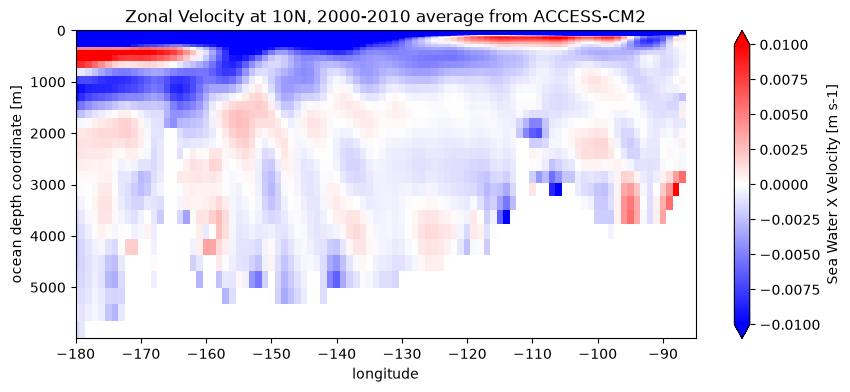

In [105]:
plt.figure(figsize=(10,4))
U_10N_mean = section.mean("time")
U_10N_mean.plot(
    x="longitude",
    y="lev",
    yincrease=False,
    vmin=-0.01, vmax=0.01, cmap="bwr")
plt.xlim(-180,-85)
plt.xticks(np.arange(-180, -85, 10))
plt.title('Zonal Velocity at 10N, 2000-2010 average from ACCESS-CM2')

In [120]:
U_10N_prof = section.mean("time").where(
    (section.longitude >= -140) & (section.longitude <= -100),
    drop=True,
).mean('section_point')

In [121]:
U_10N_prof

<xarray.DataArray 'uo' (lev: 50)> Size: 200B
array([-0.0867337 , -0.06753363, -0.05443018, -0.04777077, -0.04503626,
       -0.04358598, -0.04151949, -0.03718195, -0.03055807, -0.02254046,
       -0.01471093, -0.00849439, -0.00452628, -0.00249574, -0.00166283,
       -0.00140023, -0.00136419, -0.00138982, -0.00144349, -0.00151812,
       -0.00165342, -0.00183606, -0.00223665, -0.00278954, -0.00339567,
       -0.00376444, -0.00364684, -0.00302671, -0.00217037, -0.0013765 ,
       -0.00077656, -0.00040393, -0.00021003, -0.00019067, -0.00046095,
       -0.0006836 , -0.00044652, -0.00056679, -0.0009455 , -0.00151886,
       -0.00155644, -0.00078717, -0.00054891,  0.00026938, -0.00019335,
       -0.00059712, -0.001784  ,         nan,         nan,         nan],
      dtype=float32)
Coordinates:
  * lev      (lev) float64 400B 5.0 15.0 25.0 ... 5.166e+03 5.499e+03 5.831e+03
Attributes:
    cell_methods:   time: mean
    comment:        Prognostic x-ward velocity component resolved by the model.
    long_name:      Sea Water X Velocity
    standard_name:  sea_water_x_velocity
    units:          m s-1

Text(0.5, 1.0, 'Zonal Velocity 2000-2010 average at 10Nfrom ACCESS-CM2')

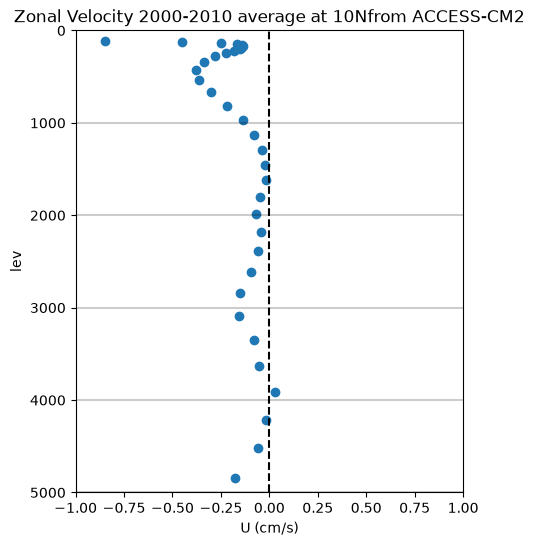

In [ ]:
plt.figure(figsize=(5,6))
plt.scatter(U_10N_prof.values*100, U_10N_prof["lev"].values)
plt.axhline(y=1000,color='k',alpha=0.2)
plt.axhline(y=2000,color='k',alpha=0.2)
plt.axhline(y=3000,color='k',alpha=0.2)
plt.axhline(y=4000,color='k',alpha=0.2)
plt.axhline(y=5000,color='k',alpha=0.2)
plt.axvline(x=0, color='k', linestyle='--')
plt.ylim(5000, 0)
plt.xlim(-1, 1)
plt.xlabel("U (cm/s)")
plt.ylabel("lev")
plt.title('Zonal Velocity 2000-2010 average at 10N from ACCESS-CM2')

This is a plot of zonal velocity from one ensemble member of `ACCESS-CM2`. The data loaded are a historical simulation from 2000 to 2010.

The original data has dimensions of (i, j) which also have (lat,lon) coordinates. To make a section at 10N, for every point in j, I select the point in i that is closest to 10N. I really have no idea how the spatial grids are laid out in these models, it would probably be good to take a closer look.

To make the profile, I take the average across the 10N section, across the whole 180E-70E region.